In [ ]:
import joblib, json, pandas as pd
from google.colab import drive

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dev_data.csv to dev_data.csv


In [ ]:
import pandas as pd
df = pd.read_csv('dev_data.csv')

IMPORTING LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats.mstats import winsorize

In [ ]:
X = df.drop('bad_flag', axis=1)
y = df['bad_flag']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
neg  = (y_train == 0).sum()
pos  = (y_train == 1).sum()
spw  = neg / pos
print(f"\n── Class Balance ────────────────────────────────────────────────")
print(f"  Negatives: {neg}, Positives: {pos}")
print(f"  scale_pos_weight = {spw:.2f}")



── Class Balance ────────────────────────────────────────────────
  Negatives: 32887, Positives: 2113
  scale_pos_weight = 15.56


In [ ]:
df.columns

Index(['customer_id', 'snapshot_month', 'age', 'income', 'months_on_book',
       'utilisation_ratio', 'missed_payments_6m', 'payment_ratio',
       'max_dpd_12m', 'cibil_score', 'num_enquiries_6m', 'num_active_trades',
       'bad_flag', 'employment_type'],
      dtype='object')

In [ ]:
df.groupby(pd.qcut(df['payment_ratio'], 10))['bad_flag'].mean()

/tmp/ipykernel_2887/4031041513.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['payment_ratio'], 10))['bad_flag'].mean()


,bad_flag
payment_ratio,
"(0.21, 0.626]",0.103159
"(0.626, 0.743]",0.090836
"(0.743, 0.836]",0.074955
"(0.836, 0.927]",0.069028
"(0.927, 1.021]",0.067786
"(1.021, 1.125]",0.057200
"(1.125, 1.246]",0.046009
"(1.246, 1.404]",0.039600
"(1.404, 1.66]",0.035600


In [ ]:
mono_map = {feat: 0 for feat in df}  # default: no constraint

domain_constraints = {
    "income": -1,
    "utilisation_ratio": +1,
    "missed_payments_6m": +1,
    "num_enquiries_6m": +1,
    "payment_ratio": -1,
    "cibil_score": -1,
}
for feat, val in domain_constraints.items():
    if feat in mono_map:
        mono_map[feat] = val

# XGBoost expects a dict or tuple; dict keyed by feature name is clearest
print("\n── Monotonicity Constraints ─────────────────────────────────────")
print({k: v for k, v in mono_map.items() if v != 0})


── Monotonicity Constraints ─────────────────────────────────────
{'income': -1, 'utilisation_ratio': 1, 'missed_payments_6m': 1, 'payment_ratio': -1, 'cibil_score': -1, 'num_enquiries_6m': 1}


+1 : Prediction must increase as feature increases

-1 : Prediction must decrease as feature increases

0  : No constraint

In [ ]:
X_num = X.select_dtypes(include=np.number)
X_num.head()

,age,income,months_on_book,utilisation_ratio,missed_payments_6m,payment_ratio,max_dpd_12m,cibil_score,num_enquiries_6m,num_active_trades
0,62,76000,66,0.2292,0,0.7112,0,702,2,15
1,52,32000,21,0.2708,0,1.1271,0,632,2,8
2,38,43000,59,0.6150,1,0.6296,0,724,3,17
3,31,41000,70,0.4922,1,1.0878,0,620,3,12
4,44,52000,17,0.1629,0,0.5755,0,561,2,13


In [ ]:
import pandas as pd
import numpy as np

# Numeric columns only
X_num = X.select_dtypes(include=np.number)

# Correlation matrix
corr_matrix = X_num.corr().abs()

# Upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)


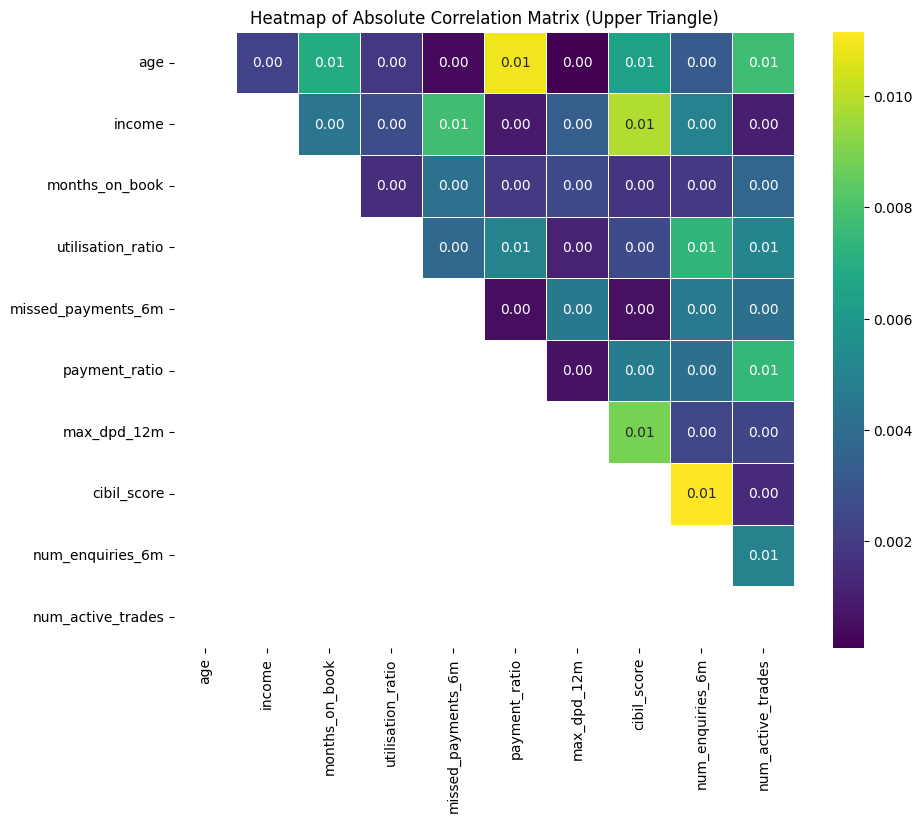

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(upper, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Heatmap of Absolute Correlation Matrix (Upper Triangle)')
plt.show()

In [ ]:
import xgboost as xgb

In [ ]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


── Model Evaluation ─────────────────────────────────────────────
  Test AUC: 0.7629

  Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     14095
           1       0.14      0.65      0.23       905

    accuracy                           0.74     15000
   macro avg       0.56      0.70      0.54     15000
weighted avg       0.92      0.74      0.81     15000



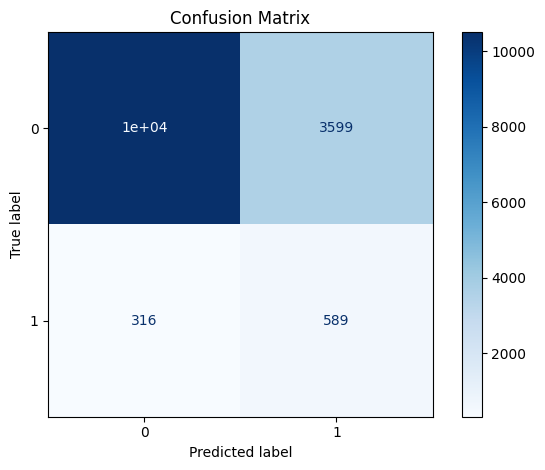

In [ ]:
model.fit(X_train, y_train, sample_weight=y_train.map({0: 1, 1: spw}),
          eval_set=[(X_test, y_test)], verbose=False)
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print("\n── Model Evaluation ─────────────────────────────────────────────")
print(f"  Test AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")
print("\n  Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

HYPER PARAMETER TUNING

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_dist = {
    "n_estimators":      [100, 200, 300, 500],
    "max_depth":         [3, 4, 5, 6],
    "learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "subsample":         [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree":  [0.6, 0.7, 0.8, 1.0],
    "min_child_weight":  [1, 3, 5, 10],
    "gamma":             [0, 0.1, 0.3, 0.5],
    "reg_alpha":         [0, 0.1, 1.0],    # L1 regularization
    "reg_lambda":        [1, 1.5, 2.0],    # L2 regularization
}

# Filter mono_map to only include features present in X_train
filtered_mono_map = {k: v for k, v in mono_map.items() if k in X_train.columns}

base_model = xgb.XGBClassifier(
    objective          = "binary:logistic",
    eval_metric        = "auc",
    scale_pos_weight   = spw,
    monotone_constraints = filtered_mono_map, # Use the filtered map
    use_label_encoder  = False,
    random_state       = 42,
    n_jobs             = -1,
    enable_categorical = True # Add this line to handle categorical features
)

search = RandomizedSearchCV(
    estimator          = base_model,
    param_distributions= param_dist,
    n_iter             = 30,          # increase for better coverage
    scoring            = "roc_auc",
    cv                 = 5,
    verbose            = 1,
    random_state       = 42,
    n_jobs             = -1,
)

search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:47:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='auc',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           num_parallel_tree=None, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6],
                                        'min_child_weight': [1, 3, 5, 10],
                                        'n_estimators': [100, 200, 300, 500],
                                        'reg_alpha': [0, 0.1, 1.0],
                                        'reg_lambda': [1, 1.5, 2.0],
                                        'subsample': [0.6, 0.7, 0.8, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [ ]:
best_model = search.best_estimator_
print(search.best_params_)

{'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}


In [ ]:
y_pred_prob = best_model.predict_proba(X_test)[:, 1] #Evaluate on test data

In [ ]:
model_new = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    reg_lambda=2.0,
    reg_alpha=0.1,
    min_child_weight=1,
    gamma=0.1,
    enable_categorical=True # Enable experimental categorical feature support
)


── Model Evaluation ─────────────────────────────────────────────
  Test AUC: 0.7629

  Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84     14095
           1       0.14      0.65      0.23       905

    accuracy                           0.74     15000
   macro avg       0.56      0.70      0.54     15000
weighted avg       0.92      0.74      0.81     15000



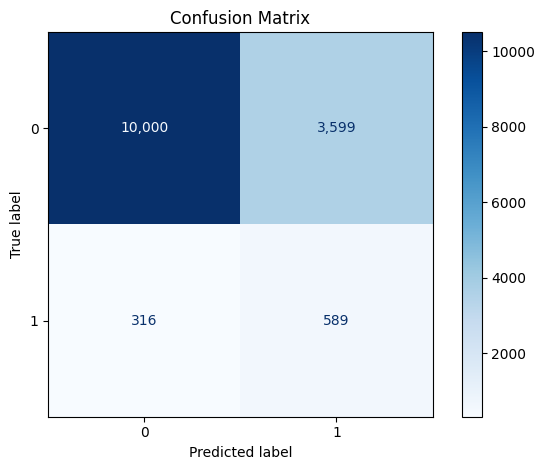

In [ ]:
model_new.fit(X_train, y_train, sample_weight=y_train.map({0: 1, 1: spw}),
          eval_set=[(X_test, y_test)], verbose=False)
y_pred      = model_new.predict(X_test)
y_pred_prob = model_new.predict_proba(X_test)[:, 1]

print("\n── Model Evaluation ─────────────────────────────────────────────")
print(f"  Test AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")
print("\n  Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")

# Format the text labels to display full integers
for labels in disp.text_:
    for label in labels:
        label.set_text(f'{int(float(label.get_text())):,}')

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
model.fit(X_train, y_train)
baseline_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

model_new = search.best_estimator_
tuned_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1])

In [ ]:
test_pred = model.predict_proba(X_test)[:,1]
test_auc = roc_auc_score(y_test, test_pred)

In [ ]:
print(f" Test AUC: {tuned_auc:.4f}")

 Test AUC: 0.7686


In [ ]:
print(f"Baseline AUC: {baseline_auc:.4f}, Tuned AUC: {tuned_auc:.4f}")

Baseline AUC: 0.7674, Tuned AUC: 0.7686


In [ ]:
print(search.best_params_)
print(search.best_score_)

{'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}
0.7612112717162975



── Feature Importance (gain) ────────────────────────────────────
max_dpd_12m           246.051102
payment_ratio         163.535339
missed_payments_6m    161.590683
utilisation_ratio     151.199554
cibil_score            91.531906
num_enquiries_6m       52.058929
months_on_book         37.294201
age                    36.549953
num_active_trades      28.719501
income                 27.907528
employment_type        24.261761
dtype: float64


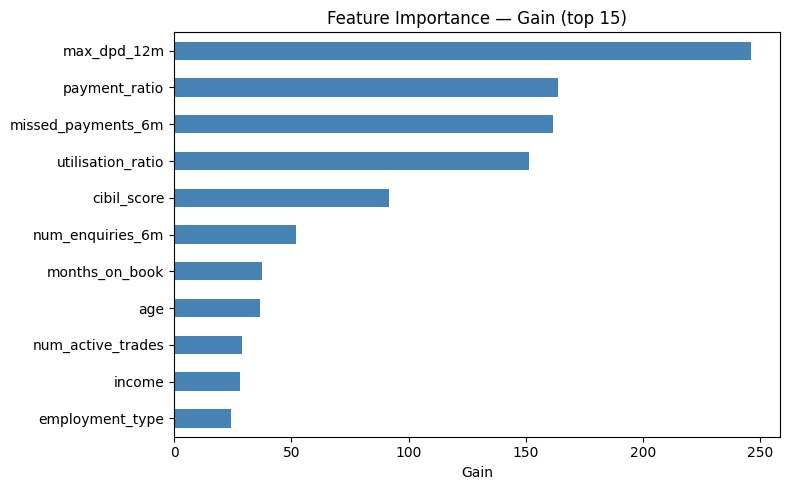

In [ ]:
print("\n── Feature Importance (gain) ────────────────────────────────────")
fi_gain = (pd.Series(best_model.get_booster().get_score(importance_type="gain"))
             .sort_values(ascending=False))
print(fi_gain)

fig, ax = plt.subplots(figsize=(8, 5))
fi_gain.head(15).plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title("Feature Importance — Gain (top 15)")
ax.set_xlabel("Gain")
plt.tight_layout()
plt.savefig("feature_importance_gain.png", dpi=150)
plt.show()


── SHAP Values ──────────────────────────────────────────────────


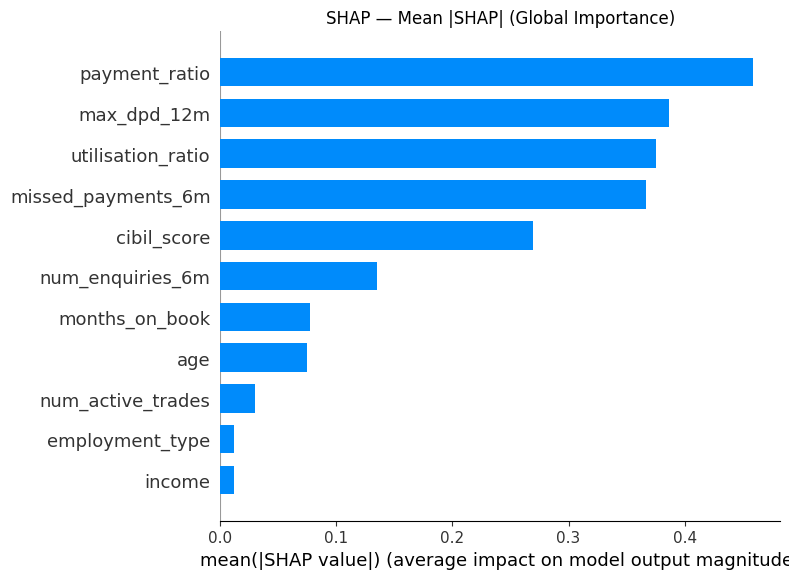

In [ ]:
import shap
from shap import TreeExplainer, waterfall_plot
print("\n── SHAP Values ──────────────────────────────────────────────────")
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Global summary plot (bar = mean |SHAP|)
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  show=False, max_display=15)
plt.title("SHAP — Mean |SHAP| (Global Importance)")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150)
plt.show()

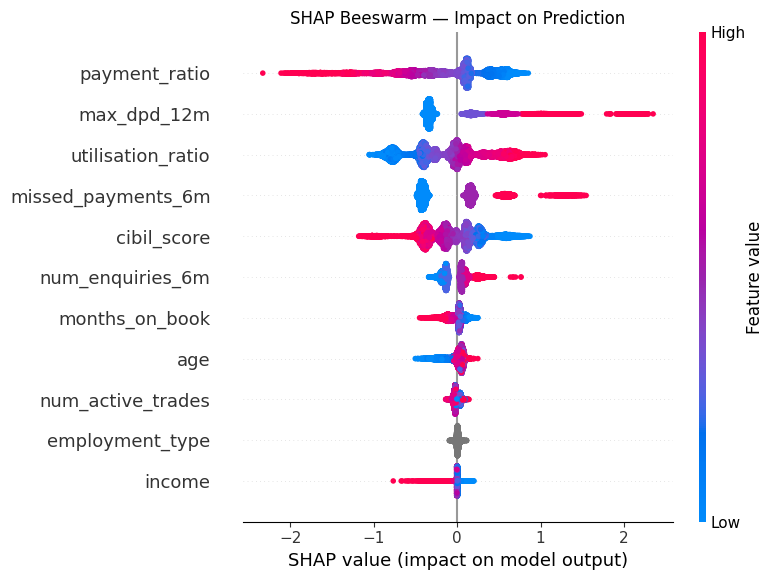

In [ ]:
# Beeswarm plot (shows direction + magnitude of each feature's impact)
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title("SHAP Beeswarm — Impact on Prediction")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=150)
plt.show()

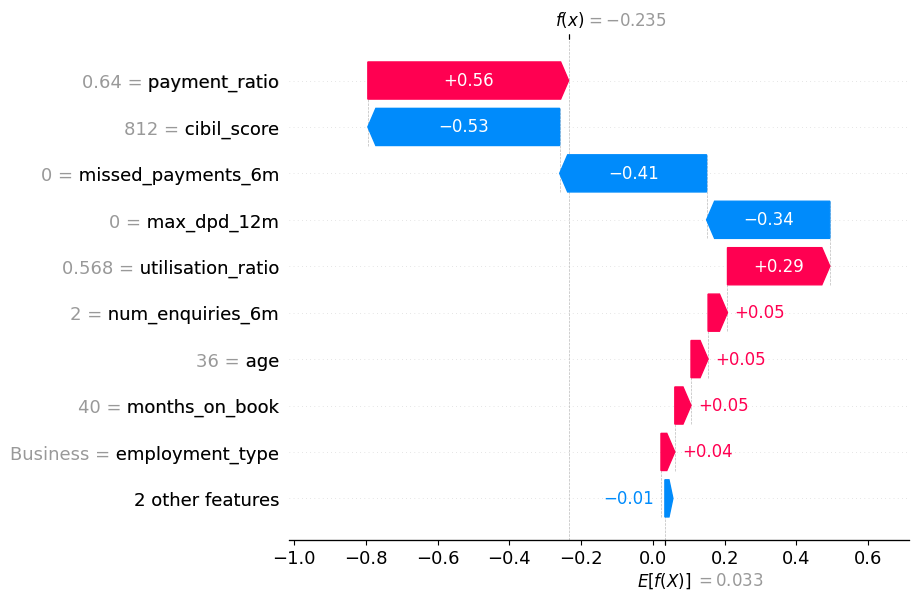

<Figure size 640x480 with 0 Axes>

In [ ]:
# Single prediction explanation (row 0 as example)
shap.waterfall_plot(shap.Explanation(
    values     = shap_values[0],
    base_values= explainer.expected_value,
    data       = X_test.iloc[0],
    feature_names=X_test.columns.tolist()
))
plt.tight_layout()
plt.savefig("shap_waterfall_row0.png", dpi=150)
plt.show()

In [ ]:
import json, pickle

best_model.save_model("xgboost_model.json")   # portable JSON format
print("\nModel saved → xgboost_model.json")

In [ ]:
model_new.fit(X_train, y_train)

train_pd = model_new.predict_proba(X_train)[:, 1]
test_pd  = model_new.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:54:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Brier Score

In [ ]:
from sklearn.metrics import brier_score_loss

train_brier = brier_score_loss(y_train, train_pd)
test_brier  = brier_score_loss(y_test, test_pd)

print(train_brier)
print(test_brier)

0.18482365440738607
0.18661216368645267


Lift Chart

In [ ]:
import pandas as pd

lift_df = pd.DataFrame({
    'actual': y_test,
    'pd': test_pd
})

lift_df['decile'] = pd.qcut(
    lift_df['pd'],
    10,
    labels=False,
    duplicates='drop'
)

lift_df['decile'] = 9 - lift_df['decile']

decile_stats = lift_df.groupby('decile').agg(
    bads=('actual','sum'),
    total=('actual','count')
)

decile_stats['bad_rate'] = (
    decile_stats['bads']
    / decile_stats['total']
)

In [ ]:
overall_bad_rate = y_test.mean()

decile_stats['lift'] = (
    decile_stats['bad_rate']
    / overall_bad_rate
)

In [ ]:
print(f"Overall Bad Rate: {overall_bad_rate * 100.4:.4f}")

Overall Bad Rate: 6.0575


Gains Chart

In [ ]:
decile_stats = decile_stats.sort_index()

decile_stats['cum_bads'] = (
    decile_stats['bads']
    .cumsum()
)

decile_stats['gain_pct'] = (
    decile_stats['cum_bads']
    / decile_stats['bads'].sum()
)

bins = pd.qcut(
    train_pd,
    10,
    duplicates='drop',
    retbins=True
)[1]

# Calculate counts first, then normalize manually
train_cut_counts = pd.cut(
    train_pd,
    bins=bins,
    include_lowest=True
).value_counts()
train_dist = train_cut_counts / train_cut_counts.sum()

test_cut_counts = pd.cut(
    test_pd,
    bins=bins,
    include_lowest=True
).value_counts()
test_dist = test_cut_counts / test_cut_counts.sum()

eps = 0.0001

train_dist += eps
test_dist += eps

psi = (
    (test_dist - train_dist)
    * np.log(test_dist / train_dist)
).sum()

print(f"PSI : {psi:.4f}")

PSI : 0.0004


In [1]:
import numpy as np

PDO = 20
factor = PDO / np.log(2)

print(factor)

28.85390081777927
